# Анализ корреляций между признаками

Цель: оценить линейные связи между признаками внутри каждой тематической группы и по всему набору данных. Выявить мультиколлинеарность и предложить кандидатов на исключение.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

# Настройка графиков
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['figure.dpi'] = 120

FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка данных

In [2]:
df_raw = pd.read_excel('../data/asean_new_data.xlsx', sheet_name='DATA', na_values=['-'])

# Короткие алиасы колонок
RENAME = {
    'Foreign direct investment, net inflows (% of GDP)': 'FDI_pct_GDP',
    'Foreign direct investment, net inflows (BoP, current US$)': 'FDI_USD',
    'GDP_annual growth': 'GDP_growth',
    'Inflation, consumer prices (annual %)': 'Inflation',
    'Real interest rate (%)': 'Real_interest',
    'Trade_openess': 'Trade_openness',
    'Tariff rate, applied, weighted mean, all products (%)': 'Tariff_rate',
    'Trade in services (% of GDP)': 'Trade_in_services',
    'General Government Debt (Percent of GDP)': 'Gov_Debt',
    'External debt stocks (% of GNI)': 'Ext_Debt',
    'Total debt service (% of exports of goods, services and primary income)': 'Debt_Service',
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)': 'CO2_per_capita',
    'Energy intensity level of primary energy (MJ/$2021 PPP GDP)': 'Energy_intensity',
    'Renewable energy consumption (% of total final energy consumption)': 'Renewable_energy',
    'Individuals using the Internet (% of population)': 'Internet_users',
    'Secure Internet servers (per 1 million people)': 'Secure_servers',
    'Mobile cellular subscriptions (per 100 people)': 'Mobile_subs',
    'Population growth (annual %)': 'Pop_growth',
    'Government expenditure on education, total (% of GDP)': 'Edu_expenditure',
    'Labor force participation rate, total (% of total population ages 15+) ': 'Labor_force',
}

df = df_raw.rename(columns=RENAME).drop(columns=['-'], errors='ignore')

# Группы признаков (без таргета)
GROUPS = {
    'ВВП': ['GDP_growth'],
    'Деглобализация': ['Trade_openness', 'Tariff_rate', 'Trade_in_services'],
    'Декарбонизация': ['Renewable_energy', 'Energy_intensity', 'CO2_per_capita'],
    'Диджитализация': ['Internet_users', 'Secure_servers', 'Mobile_subs'],
    'Демография': ['Pop_growth', 'Edu_expenditure', 'Labor_force'],
    'Долг': ['Gov_Debt', 'Ext_Debt', 'Debt_Service'],
    'Инфляция': ['Inflation'],
    'Процентная ставка': ['Real_interest'],
}

TARGET = 'FDI_pct_GDP'

# Все признаки (плоский список)
ALL_FEATURES = [col for cols in GROUPS.values() for col in cols]

print('Размер датасета:', df.shape)
print('Пропуски по признакам:')
print(df[ALL_FEATURES + [TARGET]].isna().sum().to_string())

Размер датасета: (286, 22)
Пропуски по признакам:
GDP_growth           11
Trade_openness       36
Tariff_rate          12
Trade_in_services    11
Renewable_energy     11
Energy_intensity     11
CO2_per_capita       11
Internet_users       11
Secure_servers       11
Mobile_subs          11
Pop_growth           11
Edu_expenditure      10
Labor_force           0
Gov_Debt             11
Ext_Debt             86
Debt_Service         61
Inflation            10
Real_interest        28
FDI_pct_GDP          11


## 2. Матрицы корреляций внутри групп признаков

### 2.1 Группа «Деглобализация»

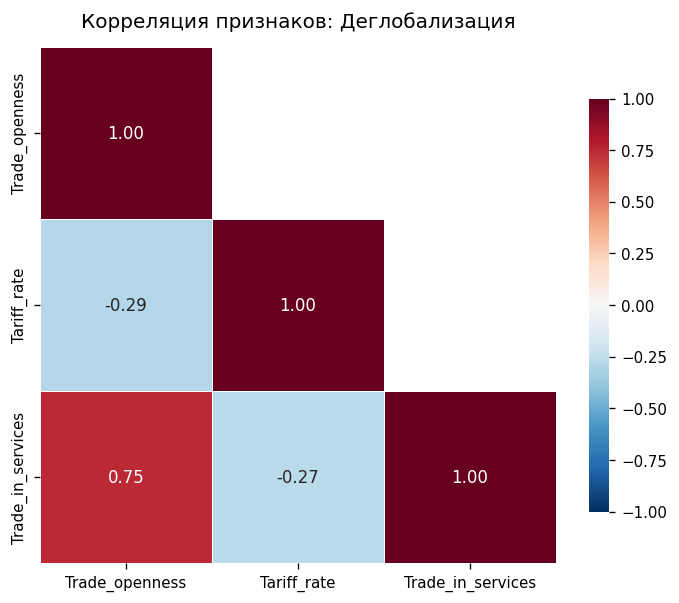

                   Trade_openness  Tariff_rate  Trade_in_services
Trade_openness           1.000000    -0.292053           0.747386
Tariff_rate             -0.292053     1.000000          -0.267627
Trade_in_services        0.747386    -0.267627           1.000000


In [3]:
def plot_corr_matrix(data, features, title, filename, annot=True, figsize=None):
    """Строит и сохраняет нижнетреугольную матрицу корреляций."""
    corr = data[features].corr()
    n = len(features)
    if figsize is None:
        figsize = (max(6, n * 1.4), max(5, n * 1.2))

    # Маска верхнего треугольника (выше диагонали)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr, mask=mask, annot=annot, fmt='.2f', cmap='RdBu_r',
        vmin=-1, vmax=1, center=0,
        square=True, linewidths=0.5,
        ax=ax, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, bbox_inches='tight')
    plt.show()
    return corr

corr_deglobal = plot_corr_matrix(
    df, GROUPS['Деглобализация'],
    'Корреляция признаков: Деглобализация',
    '01_corr_deglobalization.png'
)
print(corr_deglobal.to_string())

**Вывод:** В новых данных группа «Деглобализация» включает три принципиально разных измерения торговли: `Trade_openness` (объём торговли в % ВВП), `Tariff_rate` (тарифный барьер) и `Trade_in_services` (торговля услугами). В отличие от ранее используемых Imports/Exports, которые были суммарными компонентами `Trade_openness` (r > 0.90), новые признаки измеряют качественно иные аспекты торговли. Мультиколлинеарность внутри группы ожидаемо ниже — все три признака рекомендуется оставить для дальнейшего анализа.

### 2.2 Группа «Декарбонизация»

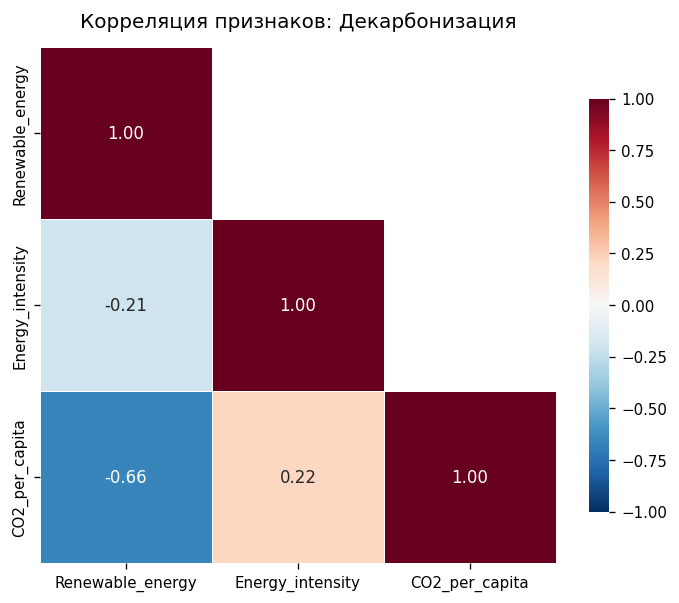

                  Renewable_energy  Energy_intensity  CO2_per_capita
Renewable_energy          1.000000         -0.208234       -0.660276
Energy_intensity         -0.208234          1.000000        0.215786
CO2_per_capita           -0.660276          0.215786        1.000000


In [4]:
corr_decarb = plot_corr_matrix(
    df, GROUPS['Декарбонизация'],
    'Корреляция признаков: Декарбонизация',
    '01_corr_decarbonization.png'
)
print(corr_decarb.to_string())

**Вывод:** Группа не имеет критической мультиколлинеарности. Наиболее тесная связь — между `Renewable_energy` и `CO2_per_capita` (r = −0.66): страны с высокой долей ВИЭ закономерно меньше выбрасывают CO₂. `Energy_intensity` практически независим от остальных (|r| ≤ 0.22). **Все три признака можно оставить** — они несут различную информацию о декарбонизационном профиле страны.

### 2.3 Группа «Диджитализация»

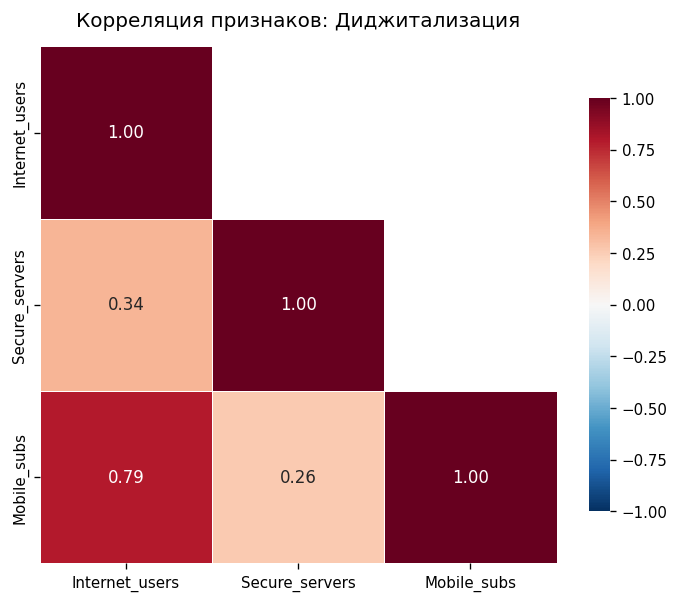

                Internet_users  Secure_servers  Mobile_subs
Internet_users         1.00000        0.341940     0.790930
Secure_servers         0.34194        1.000000     0.264299
Mobile_subs            0.79093        0.264299     1.000000


In [5]:
corr_digital = plot_corr_matrix(
    df, GROUPS['Диджитализация'],
    'Корреляция признаков: Диджитализация',
    '01_corr_digitalization.png'
)
print(corr_digital.to_string())

**Вывод:** Мультиколлинеарность присутствует: `Internet_users` и `Mobile_subs` коррелируют на уровне r = 0.79 — оба показателя отражают общий уровень цифровизации населения. `Secure_servers` независим (r ≤ 0.34 с остальными) и несёт специфическую информацию об инфраструктуре. **Рекомендуется рассмотреть удаление `Mobile_subs`**: `Internet_users` более прямолинейно измеряет цифровой охват и сильнее коррелирует с таргетом (0.34 vs 0.29).

### 2.4 Группа «Демография»

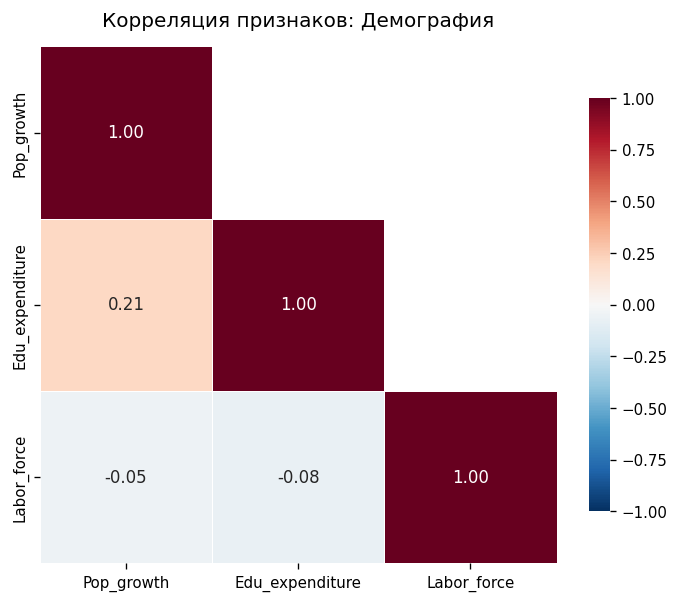

                 Pop_growth  Edu_expenditure  Labor_force
Pop_growth         1.000000         0.205296    -0.052313
Edu_expenditure    0.205296         1.000000    -0.077585
Labor_force       -0.052313        -0.077585     1.000000


In [6]:
corr_demo = plot_corr_matrix(
    df, GROUPS['Демография'],
    'Корреляция признаков: Демография',
    '01_corr_demography.png'
)
print(corr_demo.to_string())

**Вывод:** Группа полностью свободна от мультиколлинеарности — максимальная корреляция между признаками не превышает |r| = 0.21. `Pop_growth`, `Edu_expenditure` и `Labor_force` измеряют независимые аспекты демографии. **Все три признака можно оставить без ограничений.**

### 2.5 Группа «Долг»

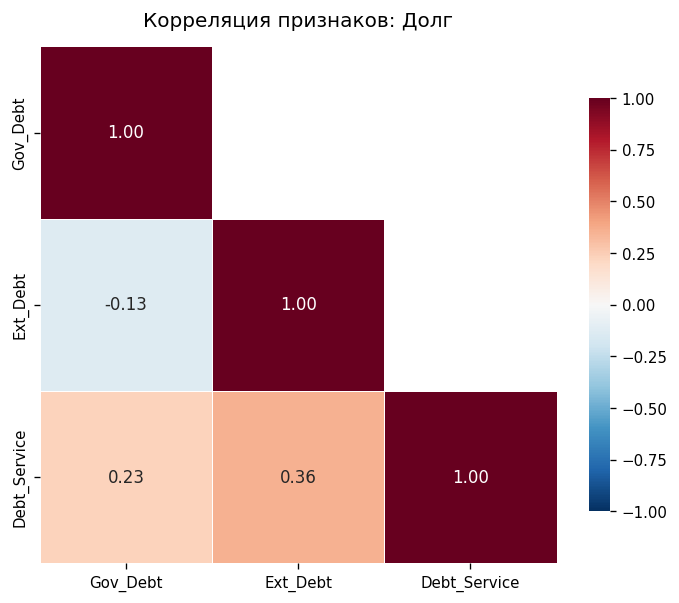

              Gov_Debt  Ext_Debt  Debt_Service
Gov_Debt      1.000000 -0.130884      0.228988
Ext_Debt     -0.130884  1.000000      0.355614
Debt_Service  0.228988  0.355614      1.000000


In [7]:
corr_debt = plot_corr_matrix(
    df, GROUPS['Долг'],
    'Корреляция признаков: Долг',
    '01_corr_debt.png'
)
print(corr_debt.to_string())

**Вывод:** Мультиколлинеарность в группе отсутствует — максимальная попарная корреляция составляет |r| = 0.36 (`Ext_Debt` и `Debt_Service`). `Gov_Debt` слабо связан с внешними долговыми показателями (r < 0.23), что говорит о различной природе внутреннего и внешнего долга в регионе. **Все три признака можно оставить.**

## 3. Глобальная матрица корреляций (все признаки + таргет)

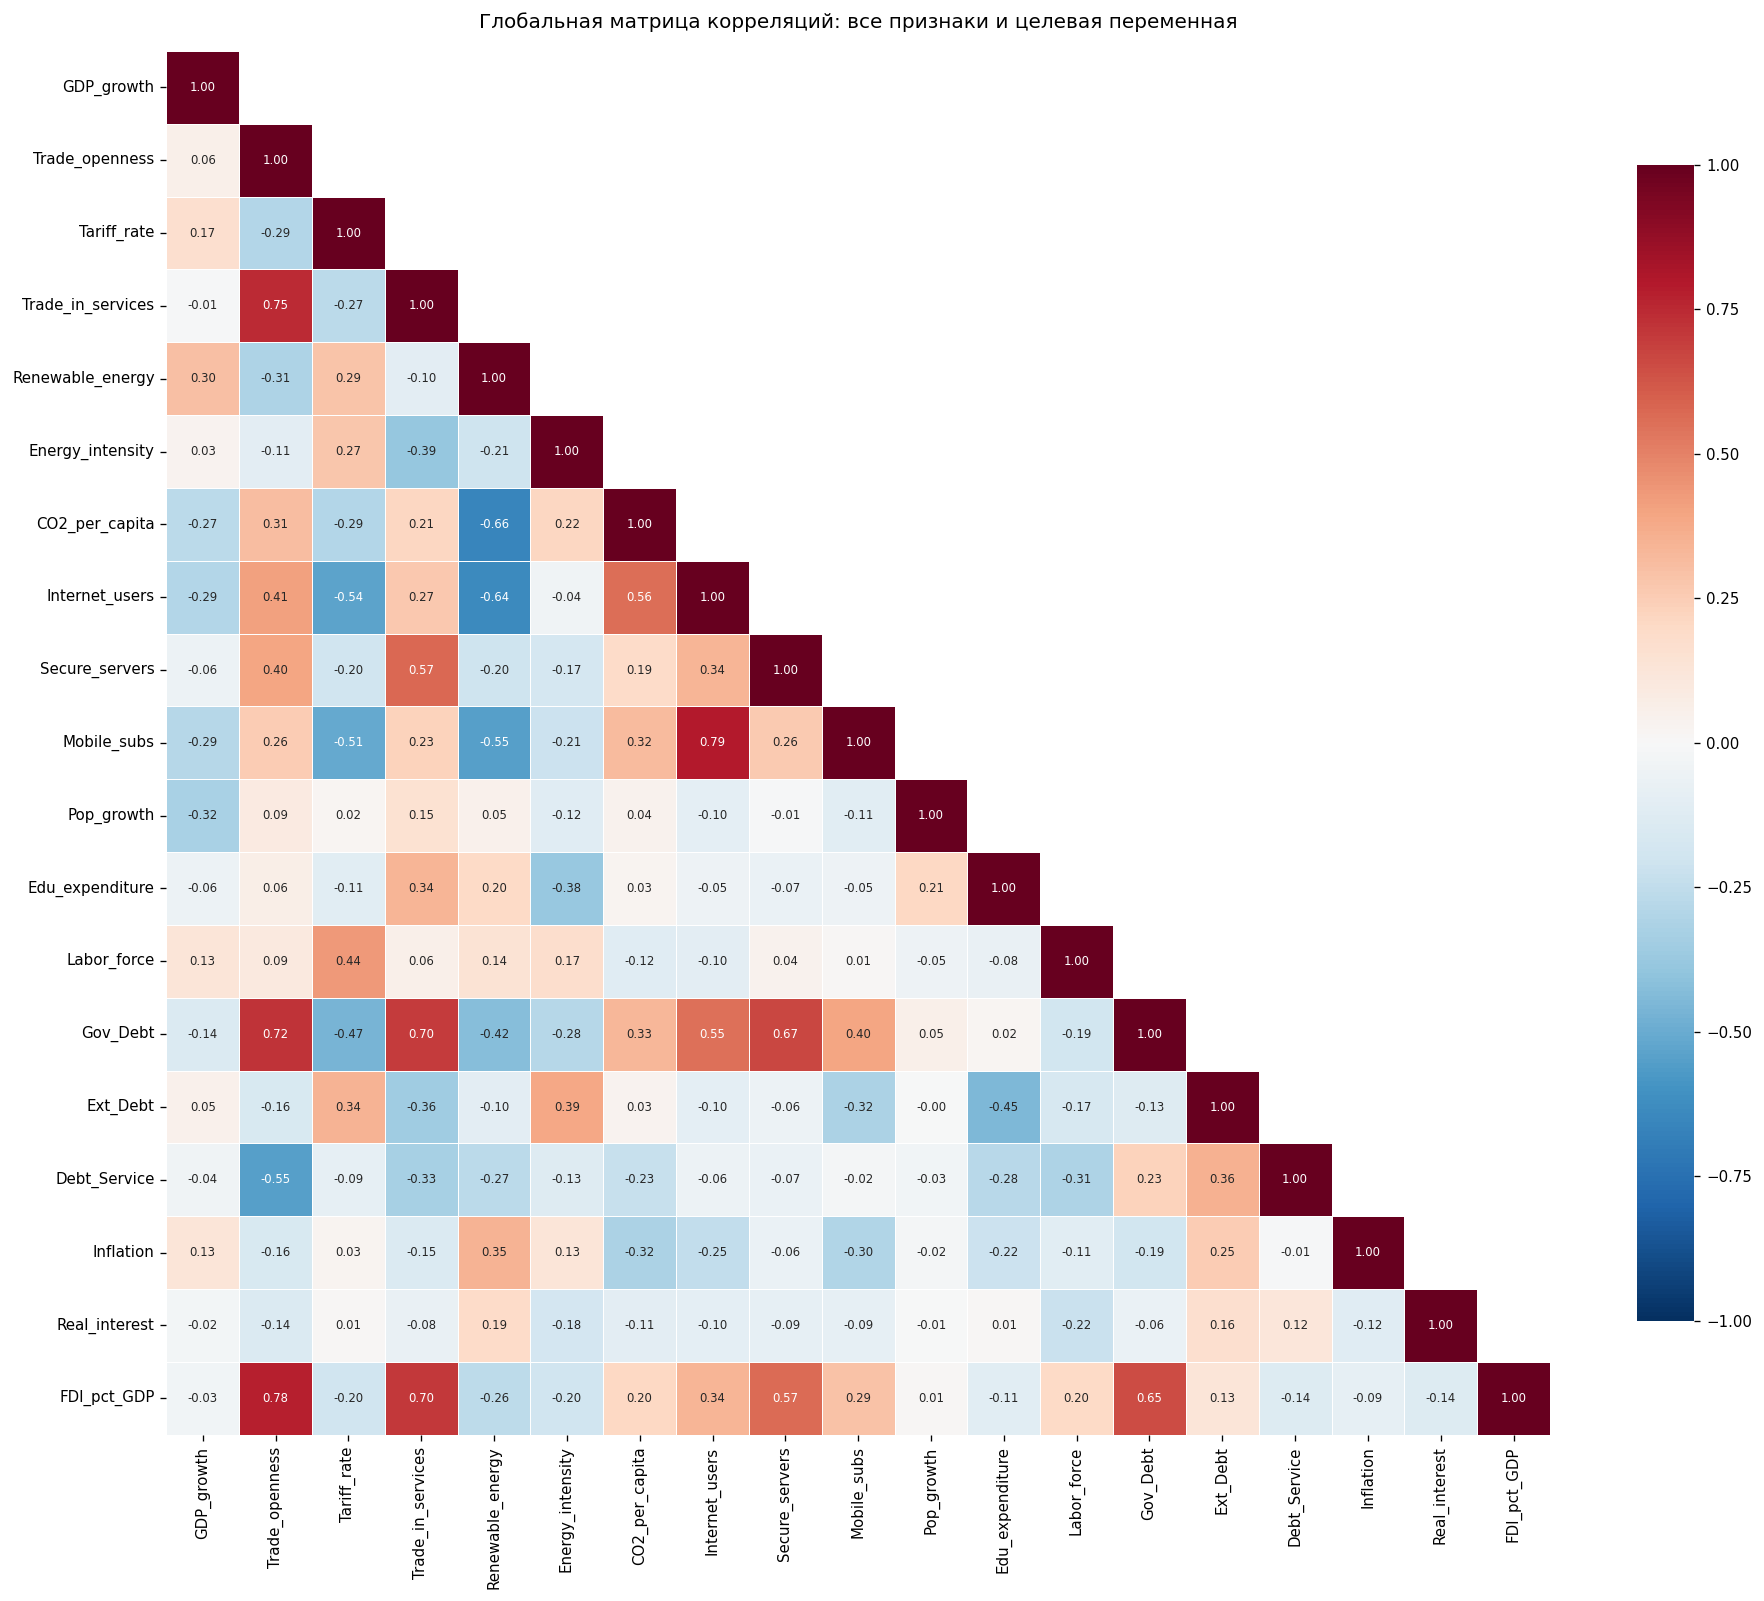

In [8]:
ALL_COLS = ALL_FEATURES + [TARGET]

corr_full = df[ALL_COLS].corr()

mask_full = np.triu(np.ones_like(corr_full, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_full, mask=mask_full, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.4,
    ax=ax, cbar_kws={'shrink': 0.75},
    annot_kws={'size': 7}
)
ax.set_title('Глобальная матрица корреляций: все признаки и целевая переменная', pad=14)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_corr_full.png', bbox_inches='tight')
plt.show()

In [9]:
# Пары с высокой мультиколлинеарностью (|r| >= 0.75, без диагонали)
THRESHOLD = 0.75

high_corr_pairs = []
for i in range(len(corr_full.columns)):
    for j in range(i + 1, len(corr_full.columns)):
        col_i = corr_full.columns[i]
        col_j = corr_full.columns[j]
        r = corr_full.iloc[i, j]
        if abs(r) >= THRESHOLD:
            high_corr_pairs.append((col_i, col_j, round(r, 3)))

df_high_corr = pd.DataFrame(high_corr_pairs, columns=['Признак 1', 'Признак 2', 'r'])
df_high_corr = df_high_corr.sort_values('r', key=abs, ascending=False)

print(f'Пары признаков с |r| >= {THRESHOLD}:')
print(df_high_corr.to_string(index=False))

Пары признаков с |r| >= 0.75:
     Признак 1   Признак 2     r
Internet_users Mobile_subs 0.791
Trade_openness FDI_pct_GDP 0.776


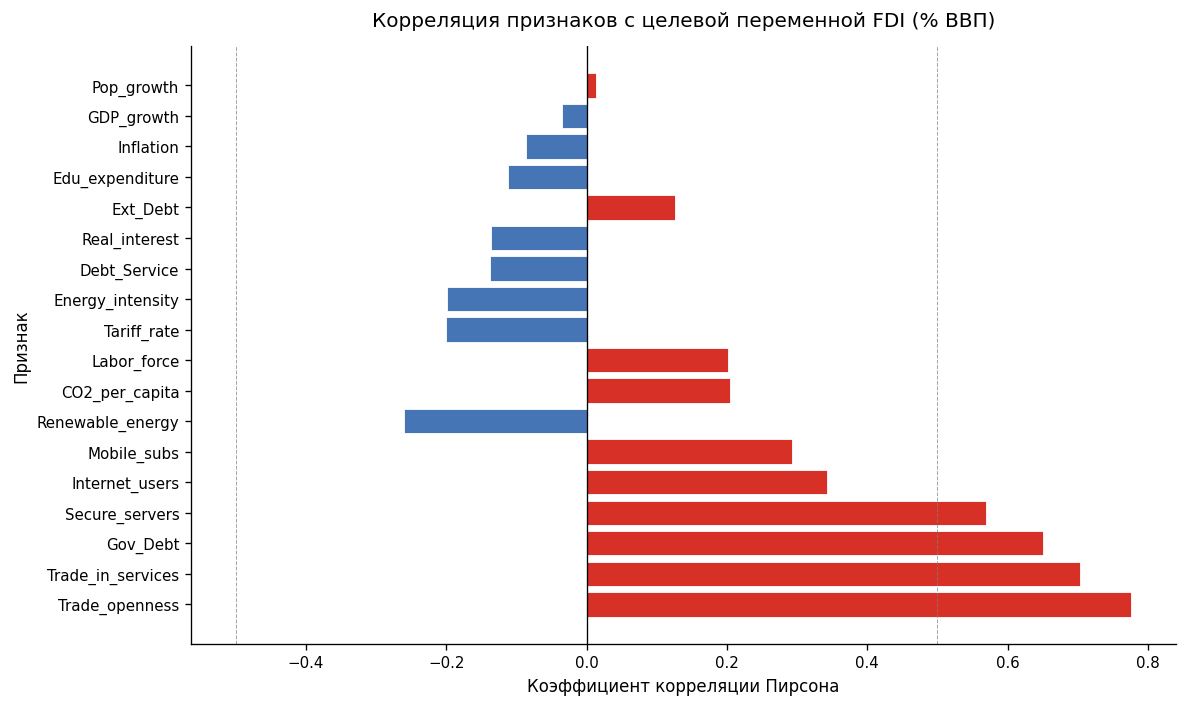


Корреляция с таргетом:
Trade_openness       0.776092
Trade_in_services    0.703687
Gov_Debt             0.651000
Secure_servers       0.569644
Internet_users       0.343008
Mobile_subs          0.292395
Renewable_energy    -0.260078
CO2_per_capita       0.204830
Labor_force          0.201064
Tariff_rate         -0.200849
Energy_intensity    -0.198404
Debt_Service        -0.137728
Real_interest       -0.136932
Ext_Debt             0.125336
Edu_expenditure     -0.111798
Inflation           -0.086715
GDP_growth          -0.034529
Pop_growth           0.013465


In [10]:
# Корреляция всех признаков с таргетом
target_corr = corr_full[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.7)
ax.set_title('Корреляция признаков с целевой переменной FDI (% ВВП)', pad=12)
ax.set_xlabel('Коэффициент корреляции Пирсона')
ax.set_ylabel('Признак')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_corr_with_target.png', bbox_inches='tight')
plt.show()

print('\nКорреляция с таргетом:')
print(target_corr.to_string())

## 4. Итоговые выводы

### Мультиколлинеарность в датасете

По всему набору данных выявлена **1 пара признаков с |r| ≥ 0.75** (без учёта корреляции с таргетом):

| Признак 1 | Признак 2 | r | Группа |
|-----------|-----------|---|--------|
| `Internet_users` | `Mobile_subs` | 0.79 | Диджитализация |

В новых данных группа «Деглобализация» переработана: вместо сильно коррелирующих `Imports_pct_GDP` и `Exports_pct_GDP` (которые были компонентами `Trade_openness`) добавлены `Tariff_rate` и `Trade_in_services` — принципиально иные измерения торговой политики и структуры. Мультиколлинеарность в этой группе существенно снизилась.

**Вывод по датасету в целом:** мультиколлинеарность сосредоточена только в группе «Диджитализация». Остальные 6 групп (включая переработанную «Деглобализацию») не создают проблем для регрессионных моделей.

### Рекомендации по удалению признаков

| Группа | Рекомендация |
|--------|-------------|
| **Деглобализация** | Оставить все три признака: `Trade_openness`, `Tariff_rate`, `Trade_in_services` — они независимы |
| **Диджитализация** | Удалить `Mobile_subs` — `Internet_users` несёт ту же информацию и сильнее коррелирует с ПИИ |
| Декарбонизация | Оставить все три признака |
| Демография | Оставить все три признака |
| Долг | Оставить все три признака |

> После удаления `Mobile_subs` итоговый набор признаков составит **17 переменных** (было 18, но теперь добавлены 2 новых взамен удалённых Imports/Exports). Это обеспечит полное покрытие новых торговых измерений.